In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/calfire_with_gridmet_terrain.csv")
print("shape: ", df.shape)
print(df.head())

shape:  (2397, 179)
   gridmet_id                              UniqueId            Name  \
0  fire_00000  3135c367-1274-4cc4-9152-661f6fd7707e      Creek Fire   
1  fire_00001  7106ba43-100b-41f9-acbf-9fb9e9ab9ef7     Taglio Fire   
2  fire_00002  ffec404e-dea9-4175-8c50-8f2b0ca3efdd    Tulloch Fire   
3  fire_00003  55fa95e6-f09e-42c4-889b-a4b5b63dccf2       Metz Fire   
4  fire_00004  ace1f464-7a70-4dcc-b8c5-d64fb1021d0e  Wheatland Fire   

  StartedDateOnly   Latitude   Longitude  AcresBurned  gridmet_rows_available  \
0      2016-10-10  38.409580 -122.431720         65.0                      30   
1      2016-04-24  37.217100 -121.080360         30.0                      30   
2      2016-05-30  37.927613 -120.528836         85.0                      30   
3      2016-05-22  36.381230 -121.200590       3876.0                      30   
4      2016-05-23  34.276000 -118.354000        156.0                      30   

   n_days_7d  pr_mm_7d_mean  ...  year  month  nwcg_size_class  se

data audit

In [3]:
print(df.isna().sum())
print(df["gridmet_id"].duplicated().sum())


# California's geographical extent is roughly between 32.5°N to 42°N latitude and 114°W to 124.5°W longitude.
if "Latitude" in df.columns and "Longitude" in df.columns:
    print("Latitude range:", df["Latitude"].min(), "to", df["Latitude"].max())
    print("Longitude range:", df["Longitude"].min(), "to", df["Longitude"].max())

if "AcresBurned" in df.columns:
    print("\nAcresBurned missing:", df["AcresBurned"].isna().sum())
    print("AcresBurned <= 0:", (df["AcresBurned"] <= 0).sum())
    
if "severity_tier" in df.columns:
    print("\nSeverity tier missing:", df["severity_tier"].isna().sum())
    print(df["severity_tier"].value_counts(dropna=False))

gridmet_id         0
UniqueId           0
Name               0
StartedDateOnly    0
Latitude           0
                  ..
elevation          0
slope_degrees      0
aspect_degrees     0
northness          0
eastness           0
Length: 179, dtype: int64
0
Latitude range: 32.557546 to 41.99483
Longitude range: -124.362017 to -114.276308

AcresBurned missing: 0
AcresBurned <= 0: 0

Severity tier missing: 0
severity_tier
Small      1311
Medium      720
Large       200
Extreme     166
Name: count, dtype: int64


In [4]:
missingness = df.isna().mean().sort_values(ascending=False).to_frame("missing_fraction")
missingness["missing_count"] = df.isna().sum()
print(missingness.head(30))

                        missing_fraction  missing_count
gridmet_id                           0.0              0
UniqueId                             0.0              0
Name                                 0.0              0
StartedDateOnly                      0.0              0
Latitude                             0.0              0
Longitude                            0.0              0
AcresBurned                          0.0              0
gridmet_rows_available               0.0              0
n_days_7d                            0.0              0
pr_mm_7d_mean                        0.0              0
pr_mm_7d_min                         0.0              0
pr_mm_7d_max                         0.0              0
pr_mm_7d_sum                         0.0              0
tmmn_K_7d_mean                       0.0              0
tmmn_K_7d_min                        0.0              0
tmmn_K_7d_max                        0.0              0
tmmn_K_7d_sum                        0.0        

feature groups

In [5]:
tier_order = ["Small", "Medium", "Large", "Extreme"]

if "severity_tier" in df.columns:
    df["severity_tier"] = pd.Categorical(df["severity_tier"], categories=tier_order, ordered=True)



In [6]:
target_cols = ["AcresBurned", "log_acres", "nwcg_size_class", "severity_tier"]
terrain_cols = [
    c for c in ["elevation", "slope_degrees", "aspect_degrees", "northness", "eastness"]
    if c in df.columns
]
weather_focus_cols = [
    c for c in [
        "tmmx_K_7d_mean",
        "tmmn_K_7d_mean",
        "vpd_kPa_7d_mean",
        "vs_m_s_7d_mean",
        "rmin_pct_7d_mean",
        "pr_mm_30d_sum",
        "erc_7d_mean",
        "bi_7d_mean",
        "fm100_pct_7d_mean",
        "fm1000_pct_30d_mean",
        "pet_mm_30d_sum",
    ]
    if c in df.columns
]

df = df.copy()

if "tmmx_K_7d_mean" in df.columns:
    df["tmmx_F_7d_mean"] = (df["tmmx_K_7d_mean"] - 273.15) * 9 / 5 + 32

if "tmmn_K_7d_mean" in df.columns:
    df["tmmn_F_7d_mean"] = (df["tmmn_K_7d_mean"] - 273.15) * 9 / 5 + 32
# converting kelvin to Fahrenheit for better interpretability
if "tmmx_K_7d_mean" in df.columns:
    df["tmmx_F_7d_mean"] = (df["tmmx_K_7d_mean"] - 273.15) * 9 / 5 + 32
if "tmmn_K_7d_mean" in df.columns:
    df["tmmn_F_7d_mean"] = (df["tmmn_K_7d_mean"] - 273.15) * 9 / 5 + 32


readable_weather_cols = [
    c for c in [
        "tmmx_F_7d_mean",
        "tmmn_F_7d_mean",
        "vpd_kPa_7d_mean",
        "vs_m_s_7d_mean",
        "rmin_pct_7d_mean",
        "pr_mm_30d_sum",
        "erc_7d_mean",
        "bi_7d_mean",
        "fm100_pct_7d_mean",
        "fm1000_pct_30d_mean",
    ]
    if c in df.columns
]

all_focus_cols = readable_weather_cols + terrain_cols

print("Terrain columns:", terrain_cols)
print("Weather/fire-danger columns:", readable_weather_cols)
print("Focus columns:", all_focus_cols)


Terrain columns: ['elevation', 'slope_degrees', 'aspect_degrees', 'northness', 'eastness']
Weather/fire-danger columns: ['tmmx_F_7d_mean', 'tmmn_F_7d_mean', 'vpd_kPa_7d_mean', 'vs_m_s_7d_mean', 'rmin_pct_7d_mean', 'pr_mm_30d_sum', 'erc_7d_mean', 'bi_7d_mean', 'fm100_pct_7d_mean', 'fm1000_pct_30d_mean']
Focus columns: ['tmmx_F_7d_mean', 'tmmn_F_7d_mean', 'vpd_kPa_7d_mean', 'vs_m_s_7d_mean', 'rmin_pct_7d_mean', 'pr_mm_30d_sum', 'erc_7d_mean', 'bi_7d_mean', 'fm100_pct_7d_mean', 'fm1000_pct_30d_mean', 'elevation', 'slope_degrees', 'aspect_degrees', 'northness', 'eastness']


,count
nwcg_size_class,
B,23
C,1288
D,448
E,272
F,200
G,166


,count
severity_tier,
Small,1311
Medium,720
Large,200
Extreme,166


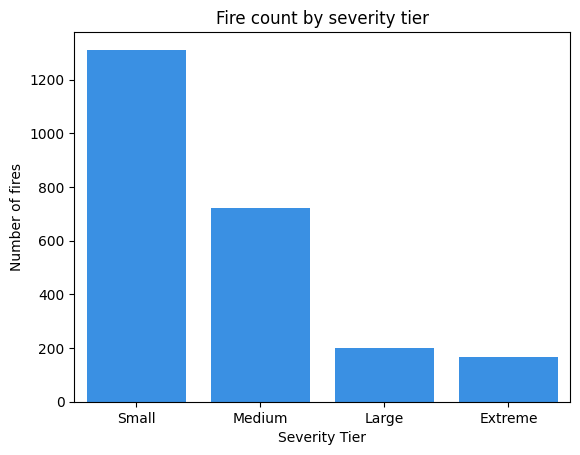

In [7]:
if "nwcg_size_class" in df.columns:
    nwcg_counts = df["nwcg_size_class"].value_counts().sort_index()
    display(nwcg_counts.to_frame("count"))
if "severity_tier" in df.columns:
    tier_counts = df["severity_tier"].value_counts().reindex(tier_order)
    display(tier_counts.to_frame("count"))

    sns.barplot(x=tier_counts.index, 
                y=tier_counts.values, 
                order=tier_order,
                 color= "dodgerblue")
    plt.title("Fire count by severity tier")
    plt.xlabel("Severity Tier")
    plt.ylabel("Number of fires")
    plt.show()

    

Final acres burned is extremely right-skewed. From the results, we can see that the median fire burned 80 acres, while the mean was 4,333 acres because a small number of very large fires pulled the average upward. The 99th percentile was 83,844 acres, and the maximum was over 1 million acres. Because of this skew, raw acreage is not ideal as the primary modeling target. The project uses log-transformed acres for exploratory analysis and NWCG-derived severity tiers for classification.

From these results, we will conclude that the raw acre regression will be too unstable to create accurate results for our model. The `log_acres` will be better for visual analysis and optimal regression and that the `severity_tier` will be the best main target.

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
AcresBurned,2397.0,4332.507772,37043.814666,2.0,30.0,80.0,328.0,2420.4,8806.4,83844.04,1032648.0


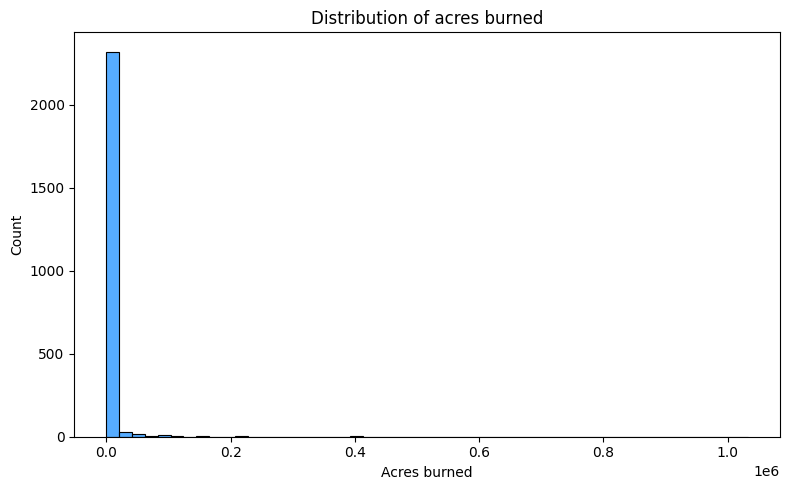

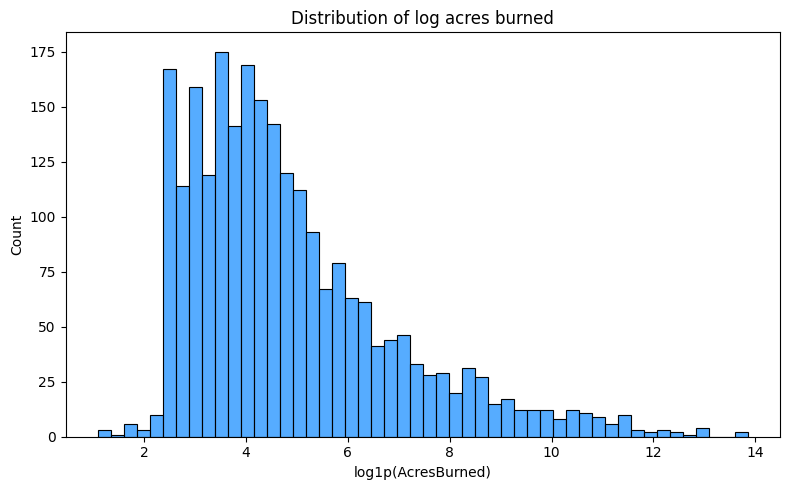

In [9]:
if "AcresBurned" in df.columns:
    display(df["AcresBurned"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).to_frame().T)

    plt.figure(figsize=(8, 5))
    sns.histplot(df["AcresBurned"], 
                 bins=50,
                 color="dodgerblue")
    plt.title("Distribution of acres burned")
    plt.xlabel("Acres burned")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


if "log_acres" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df["log_acres"], 
                 bins=50,
                 color="dodgerblue")
    plt.title("Distribution of log acres burned")
    plt.xlabel("log1p(AcresBurned)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


,count,mean,std,min,25%,50%,75%,max
severity_tier,,,,,,,,
Small,1311.0,38.124355,24.292440,2.0,17.00,32.0,55.00,99.5
Medium,720.0,302.723611,212.795904,100.0,139.75,215.0,406.25,993.0
Large,200.0,2266.005000,1114.702901,1000.0,1317.75,1964.5,2947.00,4929.0
Extreme,166.0,58216.133133,129542.814777,5000.0,8391.25,18524.0,48517.00,1032648.0


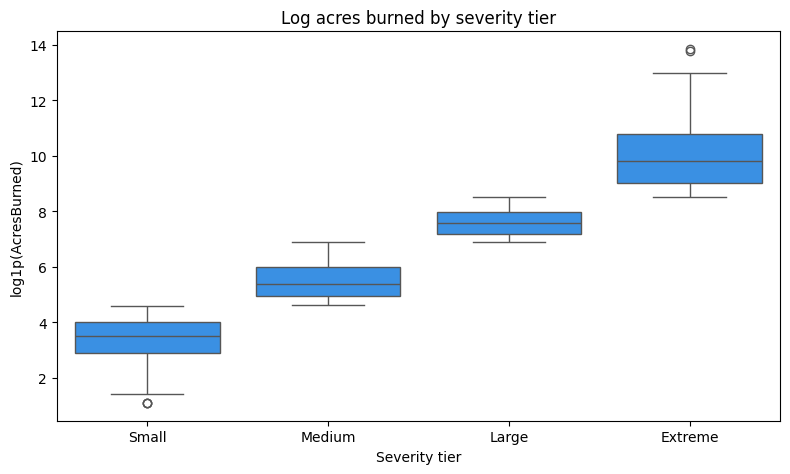

In [ ]:
if "severity_tier" in df.columns and "AcresBurned" in df.columns:
    tier_acres_summary = df.groupby("severity_tier", observed=True)["AcresBurned"].describe()
    display(tier_acres_summary)

    plt.figure(figsize=(8, 5))
    sns.boxplot(x="severity_tier", 
                y="log_acres", 
                data=df, 
                order=tier_order, 
                color="dodgerblue")
    plt.title("Log acres burned by severity tier")
    plt.suptitle("")
    plt.xlabel("Severity tier")
    plt.ylabel("log1p(AcresBurned)")
    plt.tight_layout()
    plt.show()


Temporal EDA

,count
year,
2016,149
2017,411
2018,300
2019,257
2020,241
2021,179
2022,131
2023,121
2024,608


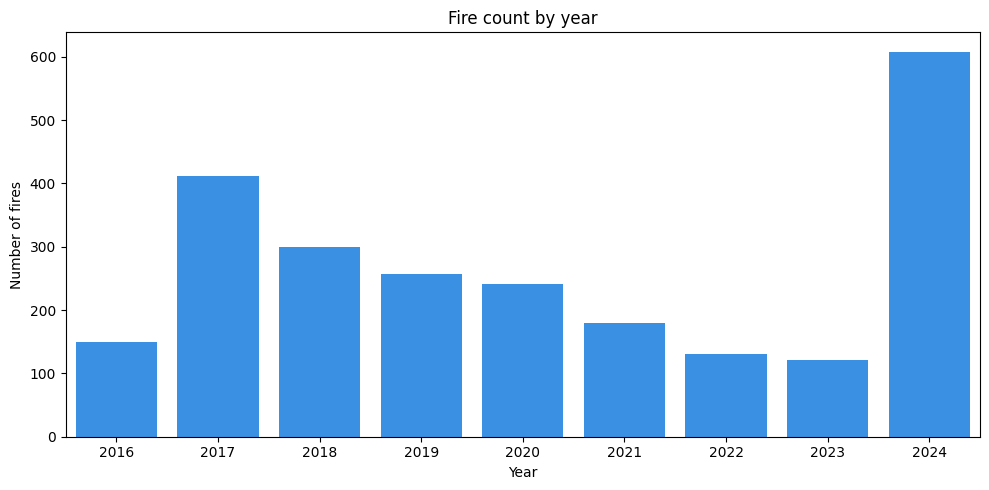

In [16]:
if "year" in df.columns:
    year_counts = df["year"].value_counts().sort_index()
    display(year_counts.to_frame("count"))
    plt.figure(figsize=(10, 5))
    sns.countplot(x="year", 
                  data=df, 
                  color="dodgerblue")
    plt.title("Fire count by year")
    plt.xlabel("Year")
    plt.ylabel("Number of fires")
    plt.tight_layout()
    plt.show()


,count
month,
1,12
2,11
3,13
4,42
5,204
6,538
7,611
8,410
9,262


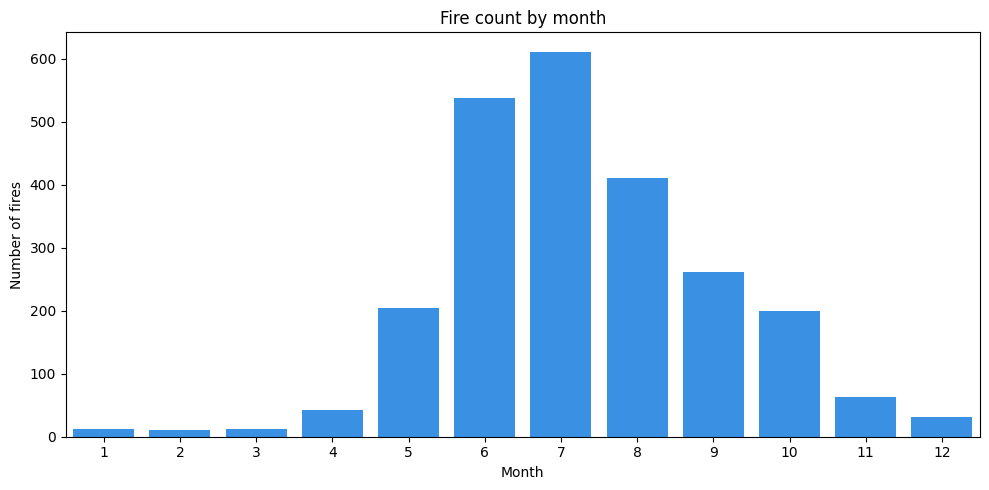

In [ ]:
if "month" in df.columns:
    month_counts = df["month"].value_counts().sort_index()
    display(month_counts.to_frame("count"))

    plt.figure(figsize=(10, 5))
    sns.barplot(x="month", 
                y="count", 
                data=month_counts.reset_index(), 
                color="dodgerblue")
    plt.title("Fire count by month")
    plt.xlabel("Month")
    plt.ylabel("Number of fires")
    plt.tight_layout()
    plt.show()


severity_tier,Small,Medium,Large,Extreme
year,,,,
2016,67,49,19,14
2017,220,117,38,36
2018,158,92,32,18
2019,136,86,25,10
2020,83,103,26,29
2021,86,63,13,17
2022,68,46,8,9
2023,71,32,10,8
2024,422,132,29,25


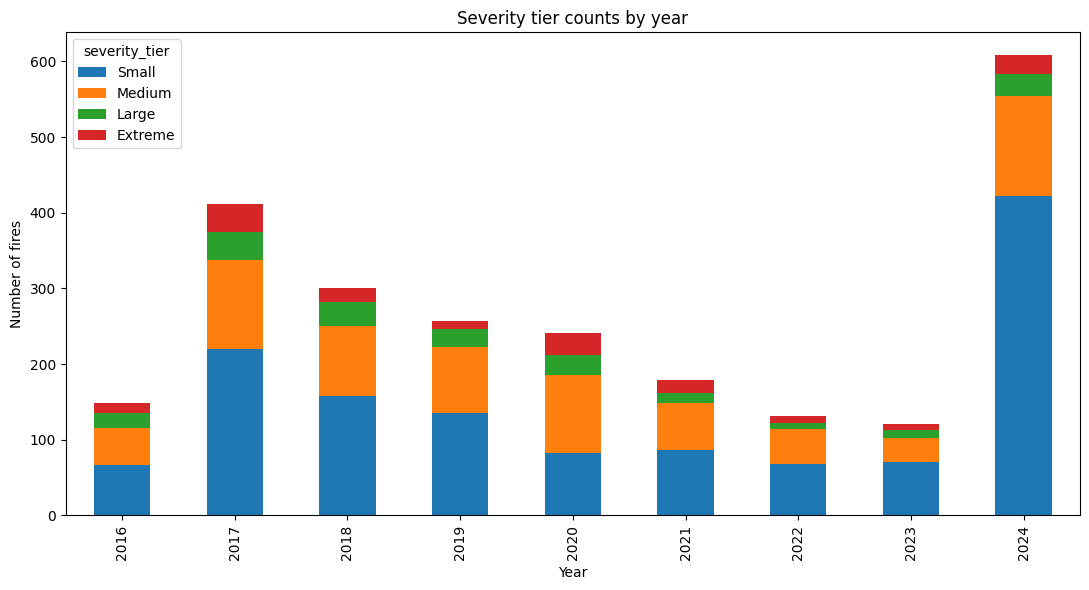

severity_tier,Small,Medium,Large,Extreme
year,,,,
2016,0.450,0.329,0.128,0.094
2017,0.535,0.285,0.092,0.088
2018,0.527,0.307,0.107,0.060
2019,0.529,0.335,0.097,0.039
2020,0.344,0.427,0.108,0.120
2021,0.480,0.352,0.073,0.095
2022,0.519,0.351,0.061,0.069
2023,0.587,0.264,0.083,0.066
2024,0.694,0.217,0.048,0.041


In [20]:
if "year" in df.columns and "severity_tier" in df.columns:
    yearly_tiers = pd.crosstab(df["year"], df["severity_tier"])
    display(yearly_tiers)

    plt.figure(figsize=(11, 6))
    yearly_tiers.plot(kind="bar", stacked=True, ax=plt.gca())
    plt.title("Severity tier counts by year")
    plt.xlabel("Year")
    plt.ylabel("Number of fires")
    plt.tight_layout()
    plt.show()

    yearly_tier_pct = pd.crosstab(df["year"], df["severity_tier"], normalize="index").round(3)
    display(yearly_tier_pct)


severity_tier,Small,Medium,Large,Extreme
month,,,,
1,8,4,0,0
2,5,4,2,0
3,8,5,0,0
4,25,14,3,0
5,120,65,15,4
6,299,174,47,18
7,329,192,46,44
8,209,115,39,47
9,137,71,26,28


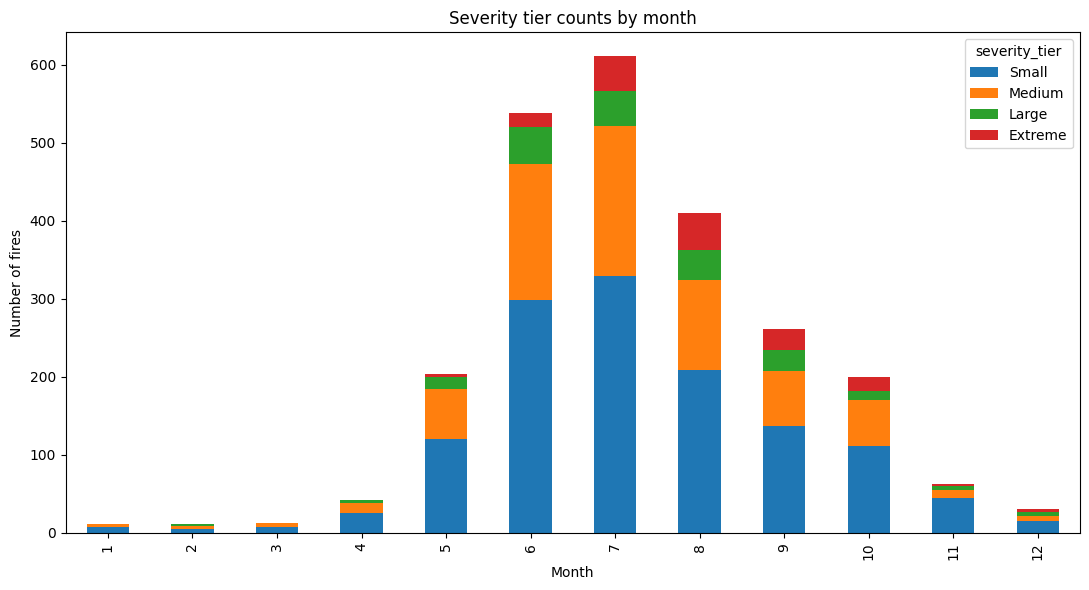

severity_tier,Small,Medium,Large,Extreme
month,,,,
1,0.667,0.333,0.000,0.000
2,0.455,0.364,0.182,0.000
3,0.615,0.385,0.000,0.000
4,0.595,0.333,0.071,0.000
5,0.588,0.319,0.074,0.020
6,0.556,0.323,0.087,0.033
7,0.538,0.314,0.075,0.072
8,0.510,0.280,0.095,0.115
9,0.523,0.271,0.099,0.107


In [21]:
if "month" in df.columns and "severity_tier" in df.columns:
    monthly_tiers = pd.crosstab(df["month"], df["severity_tier"])
    display(monthly_tiers)

    plt.figure(figsize=(11, 6))
    monthly_tiers.plot(kind="bar", stacked=True, ax=plt.gca())
    plt.title("Severity tier counts by month")
    plt.xlabel("Month")
    plt.ylabel("Number of fires")
    plt.tight_layout()
    plt.show()

    monthly_tier_pct = pd.crosstab(df["month"], df["severity_tier"], normalize="index").round(3)
    display(monthly_tier_pct)


Spatial EDA

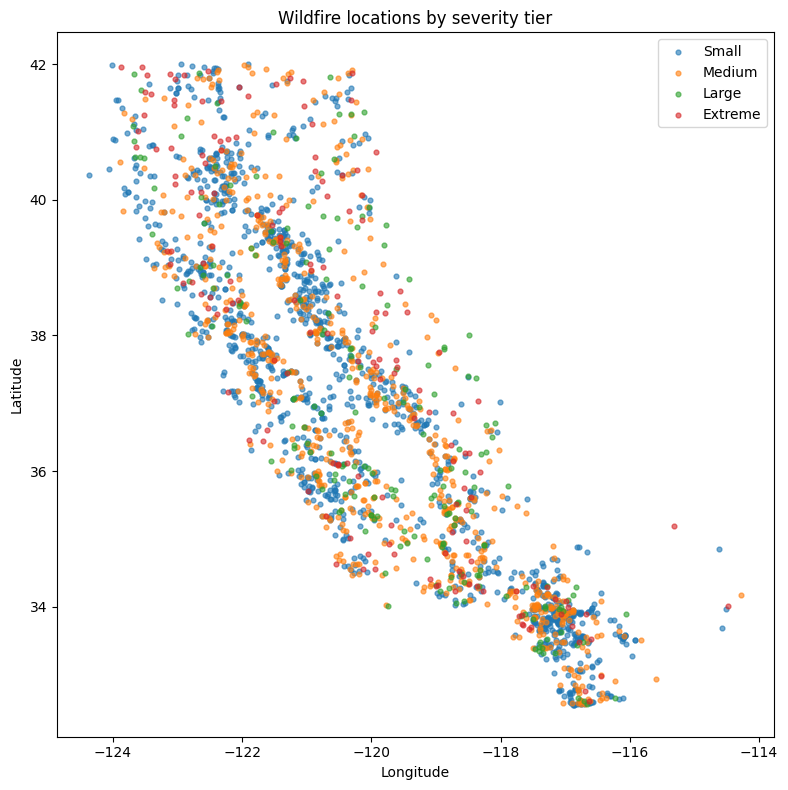

In [22]:
if {"Longitude", "Latitude", "severity_tier"}.issubset(df.columns):
    plt.figure(figsize=(8, 8))
    for tier in tier_order:
        sub = df[df["severity_tier"] == tier]
        if len(sub) == 0:
            continue
        plt.scatter(sub["Longitude"], sub["Latitude"], s=12, alpha=0.6, label=tier)

    plt.title("Wildfire locations by severity tier")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.tight_layout()
    plt.show()


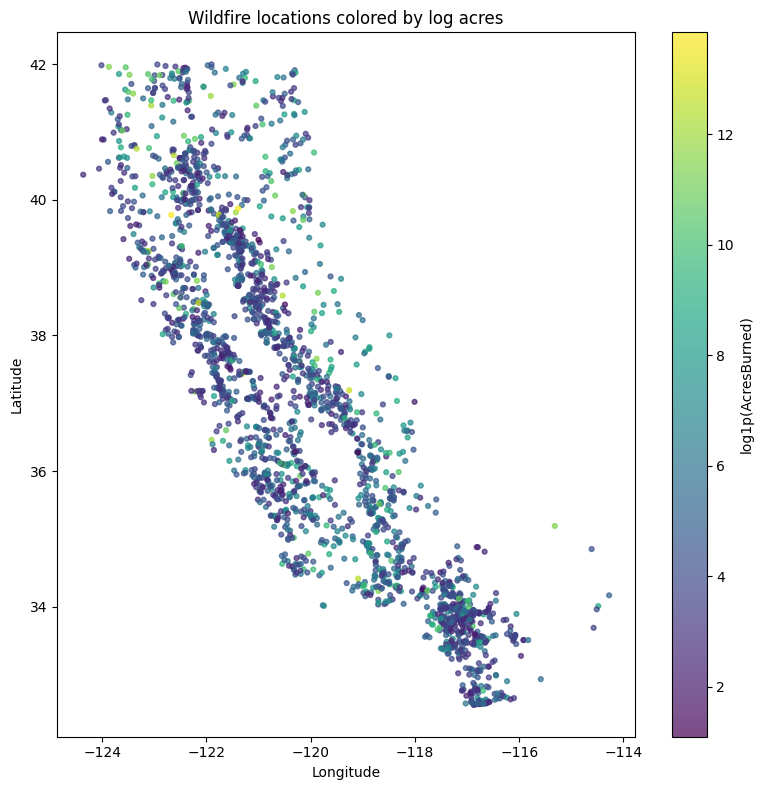

In [23]:
if {"Longitude", "Latitude", "log_acres"}.issubset(df.columns):
    plt.figure(figsize=(8, 8))
    scatter = plt.scatter(df["Longitude"], df["Latitude"], c=df["log_acres"], s=12, alpha=0.7)
    plt.title("Wildfire locations colored by log acres")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.colorbar(scatter, label="log1p(AcresBurned)")
    plt.tight_layout()
    plt.show()


Weather and fire-danger variables by severity tier 

In [25]:
if "severity_tier" in df.columns and readable_weather_cols:
    weather_by_tier_median = df.groupby("severity_tier", observed=True)[readable_weather_cols].median().round(3)
    display(weather_by_tier_median)

    weather_by_tier_mean = df.groupby("severity_tier", observed=True)[readable_weather_cols].mean().round(3)
    display(weather_by_tier_mean)

    weather_by_tier_median.to_csv("../outputs/eda_res/weather_by_tier_median.csv")

,tmmx_F_7d_mean,tmmn_F_7d_mean,vpd_kPa_7d_mean,vs_m_s_7d_mean,rmin_pct_7d_mean,pr_mm_30d_sum,erc_7d_mean,bi_7d_mean,fm100_pct_7d_mean,fm1000_pct_30d_mean
severity_tier,,,,,,,,,,
Small,87.941,57.830,1.967,3.171,21.957,0.0,64.286,49.857,8.671,10.493
Medium,88.687,58.100,2.079,3.207,20.393,0.0,68.429,51.857,8.079,9.926
Large,86.656,56.981,2.036,3.171,18.321,0.0,71.214,53.214,7.557,9.480
Extreme,88.893,57.470,2.183,2.857,17.114,0.0,75.000,53.571,6.886,8.742


,tmmx_F_7d_mean,tmmn_F_7d_mean,vpd_kPa_7d_mean,vs_m_s_7d_mean,rmin_pct_7d_mean,pr_mm_30d_sum,erc_7d_mean,bi_7d_mean,fm100_pct_7d_mean,fm1000_pct_30d_mean
severity_tier,,,,,,,,,,
Small,86.810,57.695,2.056,3.358,23.365,6.125,64.155,50.258,9.130,10.715
Medium,87.694,58.267,2.146,3.392,21.802,4.786,67.048,52.862,8.611,10.256
Large,86.146,57.154,2.103,3.269,20.686,5.134,69.009,53.418,8.225,9.878
Extreme,87.585,58.710,2.282,3.020,18.874,2.852,73.608,53.615,7.443,8.844


<Figure size 800x500 with 0 Axes>

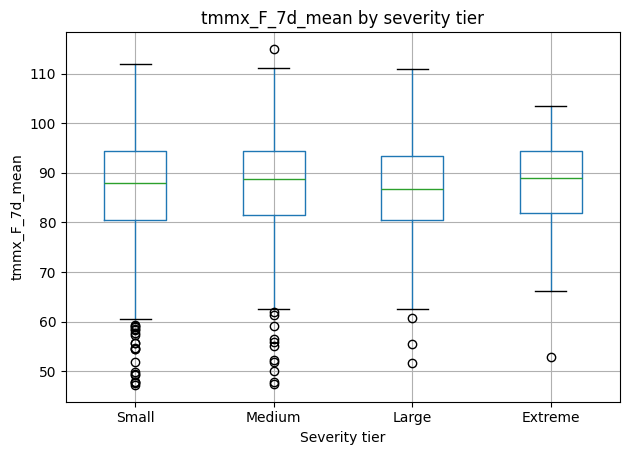

<Figure size 800x500 with 0 Axes>

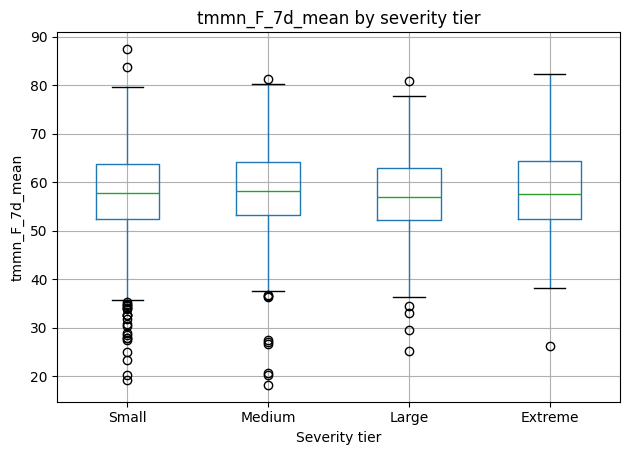

<Figure size 800x500 with 0 Axes>

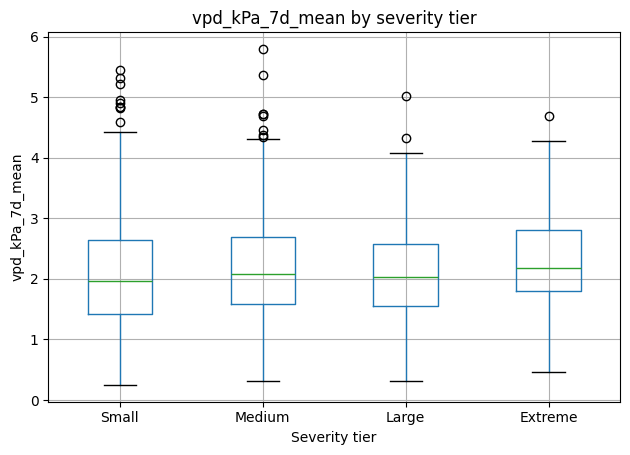

<Figure size 800x500 with 0 Axes>

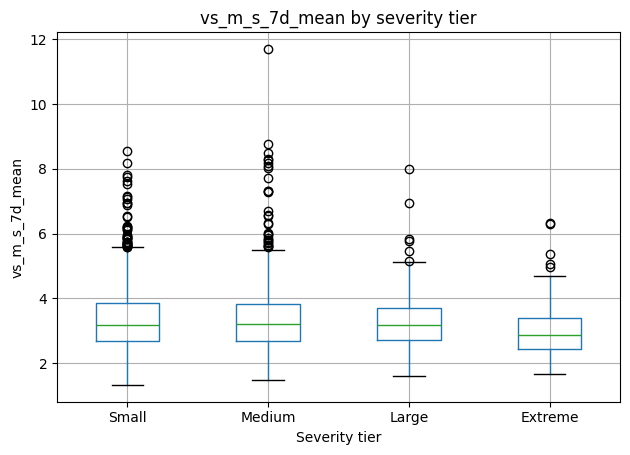

<Figure size 800x500 with 0 Axes>

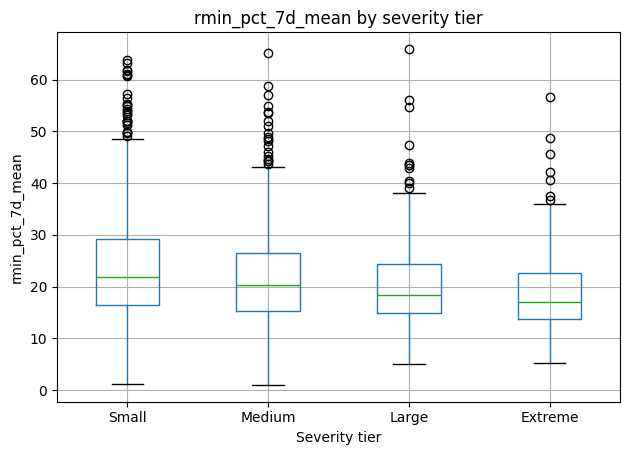

<Figure size 800x500 with 0 Axes>

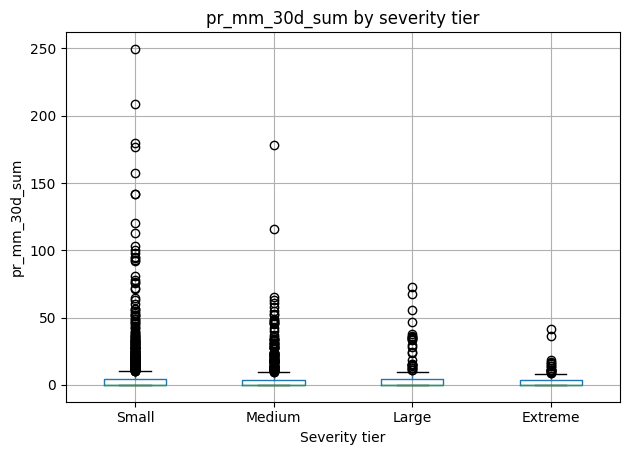

<Figure size 800x500 with 0 Axes>

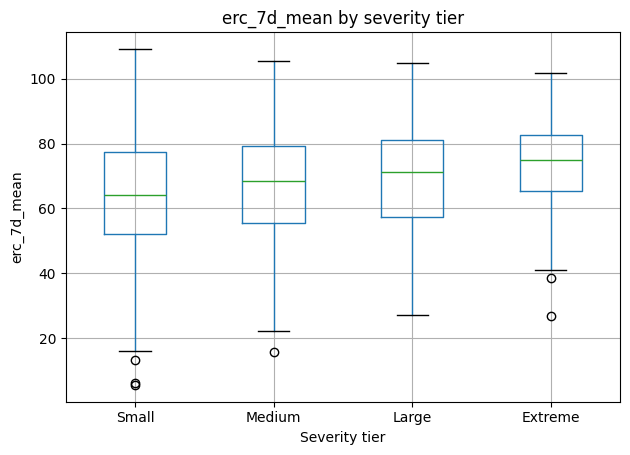

<Figure size 800x500 with 0 Axes>

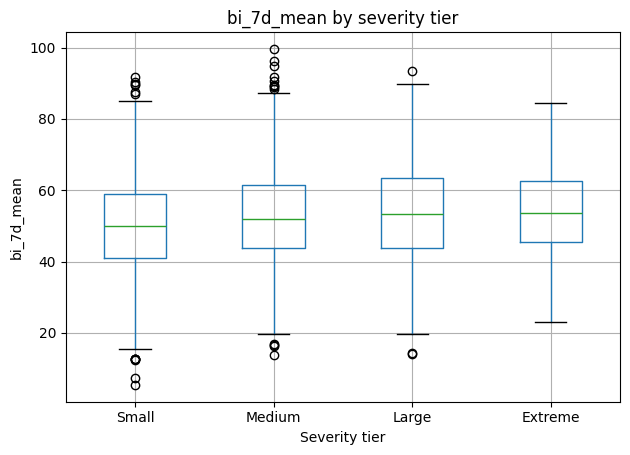

<Figure size 800x500 with 0 Axes>

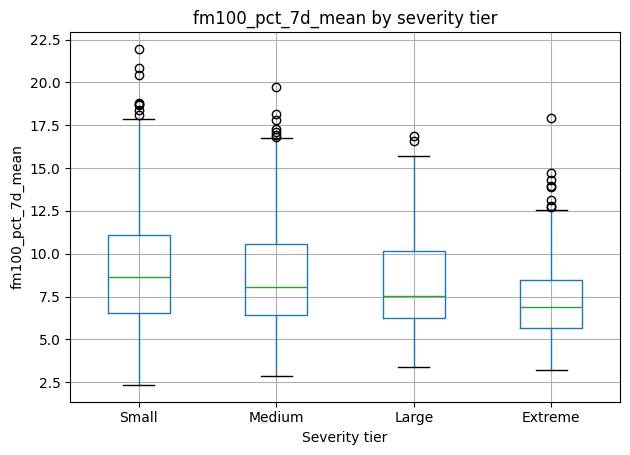

<Figure size 800x500 with 0 Axes>

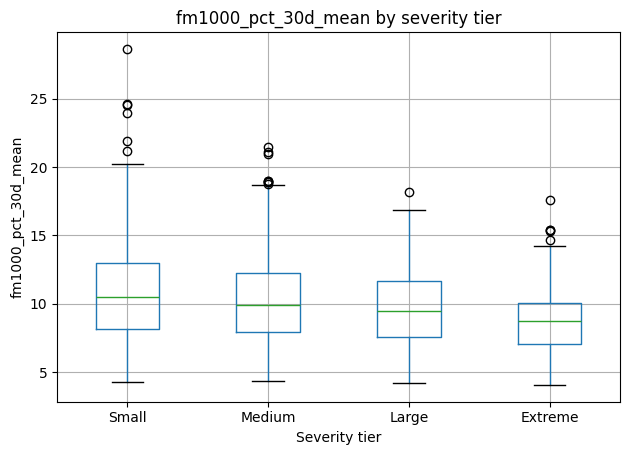

In [26]:
for col in readable_weather_cols:
    plt.figure(figsize=(8, 5))
    df.boxplot(column=col, by="severity_tier")
    plt.title(f"{col} by severity tier")
    plt.suptitle("")
    plt.xlabel("Severity tier")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


terrain variables by severity tier

In [27]:
if "severity_tier" in df.columns and terrain_cols:
    terrain_by_tier_median = df.groupby("severity_tier", observed=True)[terrain_cols].median().round(3)
    display(terrain_by_tier_median)

    terrain_by_tier_mean = df.groupby("severity_tier", observed=True)[terrain_cols].mean().round(3)
    display(terrain_by_tier_mean)

    terrain_by_tier_median.to_csv("../outputs/eda_res/terrain_by_tier_median.csv")


,elevation,slope_degrees,aspect_degrees,northness,eastness
severity_tier,,,,,
Small,361.971,4.0,208.0,-0.139,-0.342
Medium,393.131,4.0,205.0,-0.070,-0.225
Large,571.132,5.0,197.0,-0.174,-0.182
Extreme,638.145,8.0,203.0,-0.216,-0.199


,elevation,slope_degrees,aspect_degrees,northness,eastness
severity_tier,,,,,
Small,465.027,5.167,190.133,-0.089,-0.154
Medium,529.927,5.647,184.371,-0.032,-0.114
Large,781.363,7.500,176.610,-0.040,-0.091
Extreme,870.885,9.331,187.500,-0.120,-0.086


<Figure size 800x500 with 0 Axes>

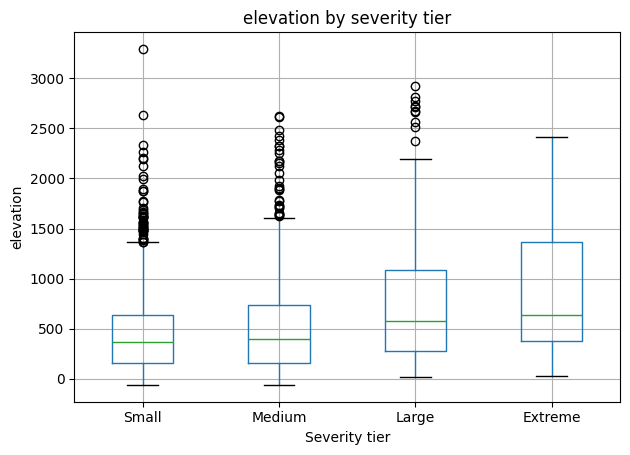

<Figure size 800x500 with 0 Axes>

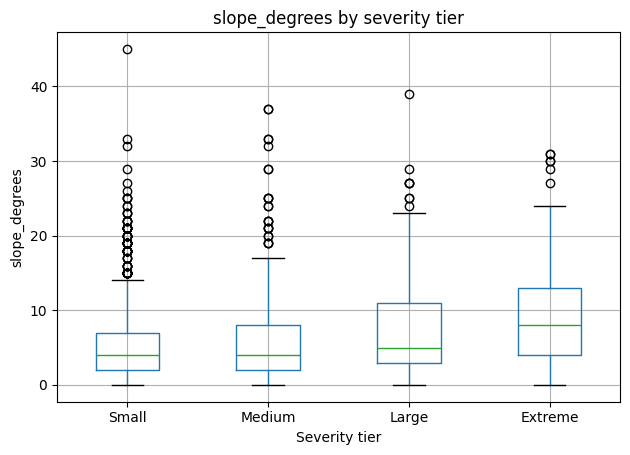

<Figure size 800x500 with 0 Axes>

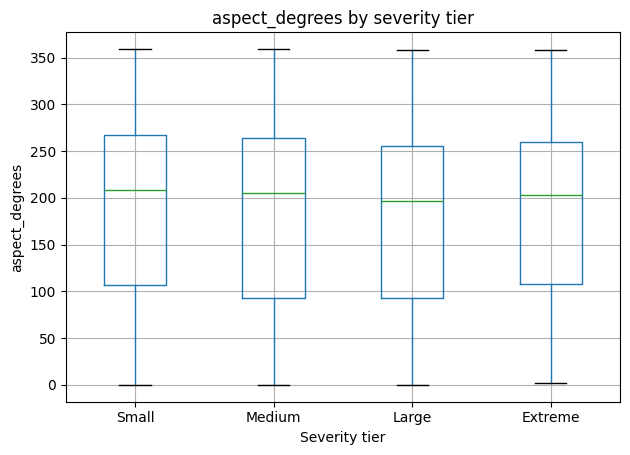

<Figure size 800x500 with 0 Axes>

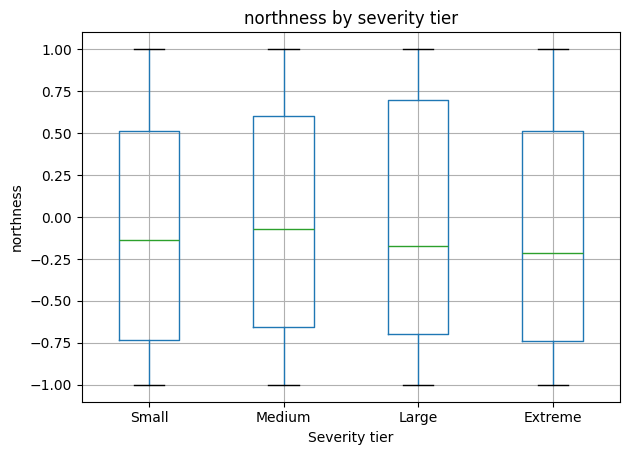

<Figure size 800x500 with 0 Axes>

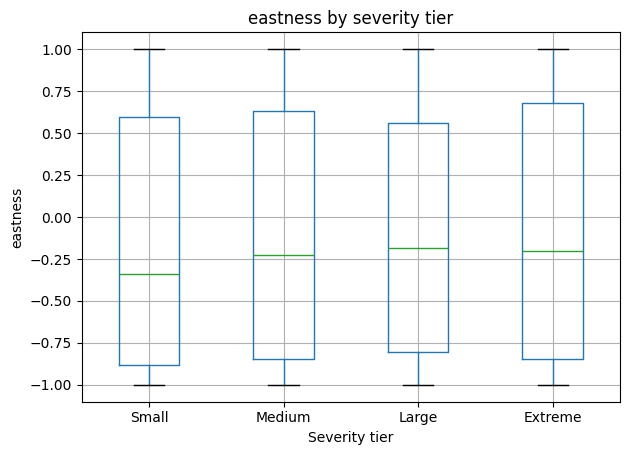

In [28]:
for col in terrain_cols:
    plt.figure(figsize=(8, 5))
    df.boxplot(column=col, by="severity_tier")
    plt.title(f"{col} by severity tier")
    plt.suptitle("")
    plt.xlabel("Severity tier")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


correlation and redundancy check